In [1]:
#Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
#Load Data
df = pd.read_csv(
    "paysim.csv.zip"
)

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
#Check Dataset Shape
df.shape

(6362620, 11)

In [5]:
#Check Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
#Check Missing Values
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
#Statistical Summary
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
#Fraud Distribution
#How many fraud transactions exist?
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
#Percentage
df['isFraud'].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

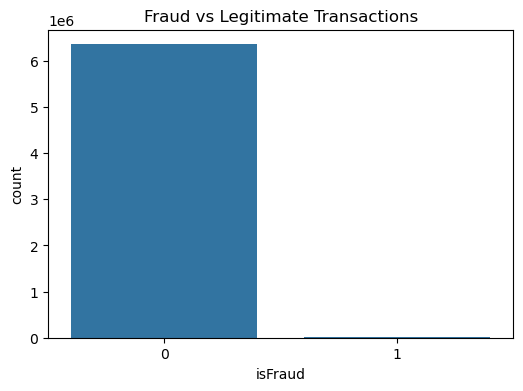

In [10]:
#Visualize Fraud Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='isFraud',
    data=df
)

plt.title("Fraud vs Legitimate Transactions")

plt.show()

In [11]:
#Transaction Type Distribution
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

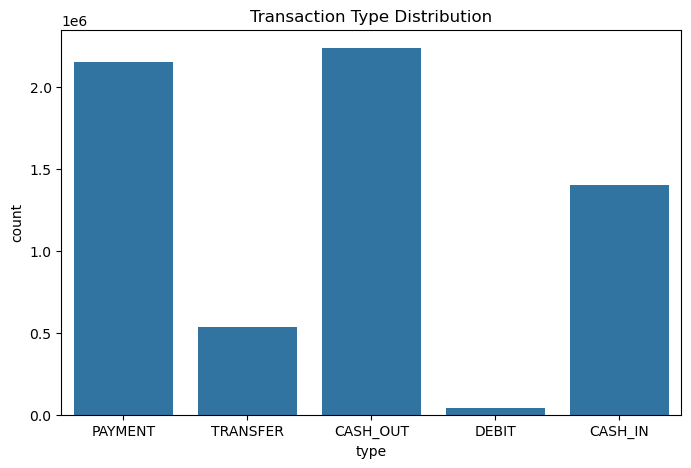

In [12]:
#Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    x='type',
    data=df
)

plt.title("Transaction Type Distribution")

plt.show()

In [13]:
#Fraud by Transaction Type
fraud_by_type = df.groupby('type')['isFraud'].sum()

fraud_by_type

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

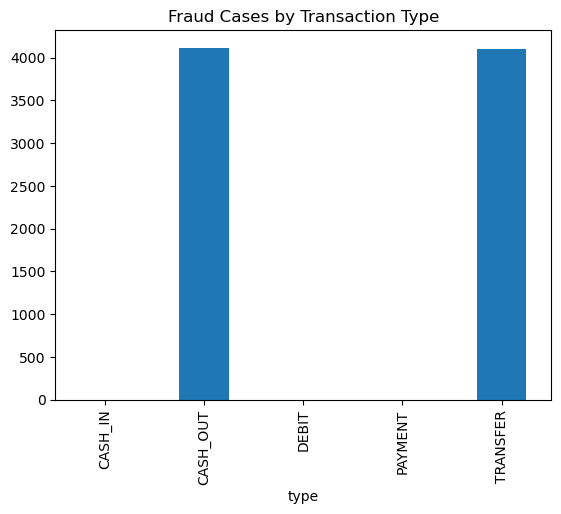

In [14]:
#Visualize
fraud_by_type.plot(
    kind='bar'
)

plt.title("Fraud Cases by Transaction Type")

plt.show()

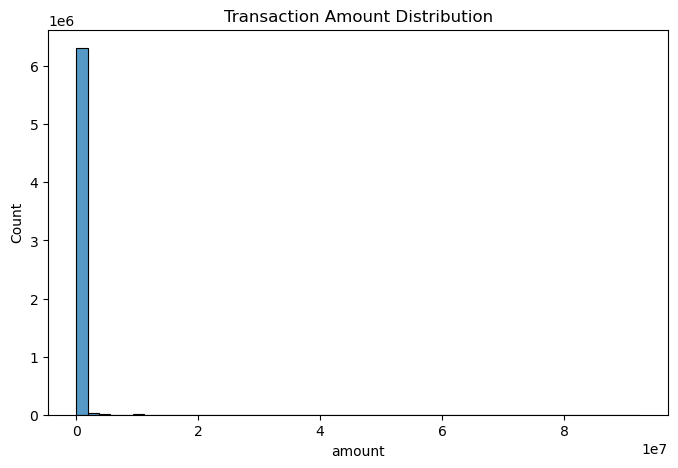

In [15]:
#Amount Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['amount'],
    bins=50
)

plt.title("Transaction Amount Distribution")

plt.show()

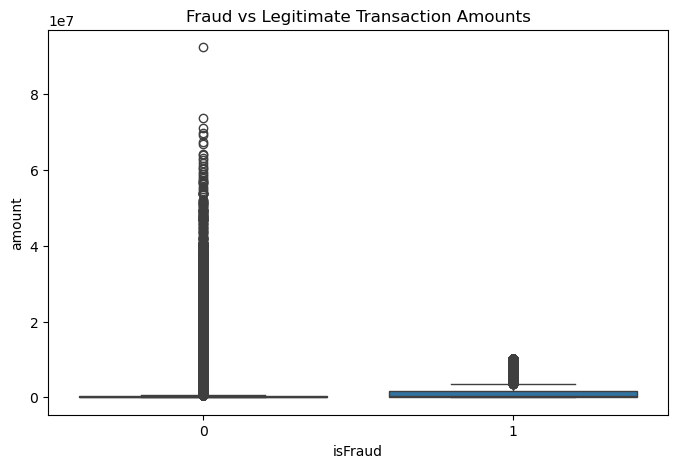

In [16]:
#Boxplot (Project Requirement)
plt.figure(figsize=(8,5))

sns.boxplot(
    x='isFraud',
    y='amount',
    data=df
)

plt.title(
    "Fraud vs Legitimate Transaction Amounts"
)

plt.show()

In [18]:
#Top Fraud Amounts
df[df['isFraud']==1] \
.sort_values(
    by='amount',
    ascending=False
) \
.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,log_amount
3760283,279,CASH_OUT,10000000.0,C1214015158,10000000.00,0.00,C2110157840,0.00,10000000.00,1,0,16.118096
5987587,409,CASH_OUT,10000000.0,C97242201,10000000.00,0.00,C786701128,8496.86,10008496.86,1,0,16.118096
1707592,160,CASH_OUT,10000000.0,C525906402,10000000.00,0.00,C43869769,2145275.47,12145275.47,1,0,16.118096
1707591,160,TRANSFER,10000000.0,C752627210,27670038.08,17670038.08,C1853789265,0.00,0.00,1,0,16.118096
1707590,160,CASH_OUT,10000000.0,C2068007279,10000000.00,0.00,C836488544,158643.25,10158643.25,1,0,16.118096
1707589,160,TRANSFER,10000000.0,C313051938,37670038.08,27670038.08,C2055653883,0.00,0.00,1,0,16.118096
6055664,497,CASH_OUT,10000000.0,C25889412,10000000.00,0.00,C1671906752,714460.87,10714460.87,1,0,16.118096
6351219,702,TRANSFER,10000000.0,C485022724,33171085.59,23171085.59,C1852255407,0.00,0.00,1,0,16.118096
6351220,702,CASH_OUT,10000000.0,C1666917384,10000000.00,0.00,C779798347,3485891.28,13485891.28,1,0,16.118096
6351221,702,TRANSFER,10000000.0,C229313332,23171085.59,13171085.59,C766725973,0.00,0.00,1,0,16.118096


In [19]:
#Fraud Rate by Transaction Type
fraud_rate = (
    df.groupby('type')['isFraud']
    .mean()
    *100
)

fraud_rate

type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64

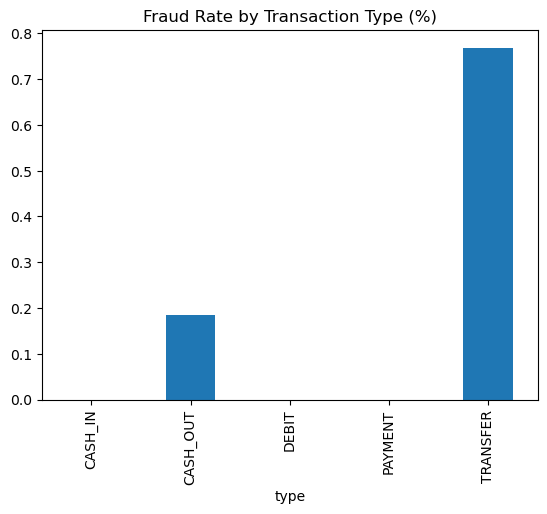

In [20]:
#Visualize
fraud_rate.plot(
    kind='bar'
)

plt.title(
    "Fraud Rate by Transaction Type (%)"
)

plt.show()